# Week 6 — Diabetes Classification (Model Comparison)
**Intern:** Sankalpa Parajuli | **Track:** AI/ML Internship

Compare **Decision Tree, Random Forest, KNN, SVM** (+ Logistic Regression as a baseline) on the Pima Indians Diabetes dataset (loaded from a public URL).
Target `Outcome`: 1 = diabetic, 0 = not diabetic.

**Metrics:** accuracy, precision, recall, F1, confusion matrix.

## Quick concepts
- **Decision Tree:** series of yes/no questions on features. Easy to read, can overfit.
- **Random Forest:** many trees voting together → more stable.
- **KNN:** looks at the *k* closest patients and takes a majority vote. Needs scaling.
- **SVM:** finds the boundary with the widest margin between classes. Needs scaling.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
sns.set_style('whitegrid')

In [2]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv', header=None, names=cols)
print(df.shape)
print(df['Outcome'].value_counts())
df.head()

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data cleaning
In this dataset a **0** in Glucose, BloodPressure, SkinThickness, Insulin or BMI is impossible → it means *missing*. Replace with NaN, then fill with the median.

In [3]:
bad = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
print((df[bad]==0).sum())
df[bad] = df[bad].replace(0, np.nan)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


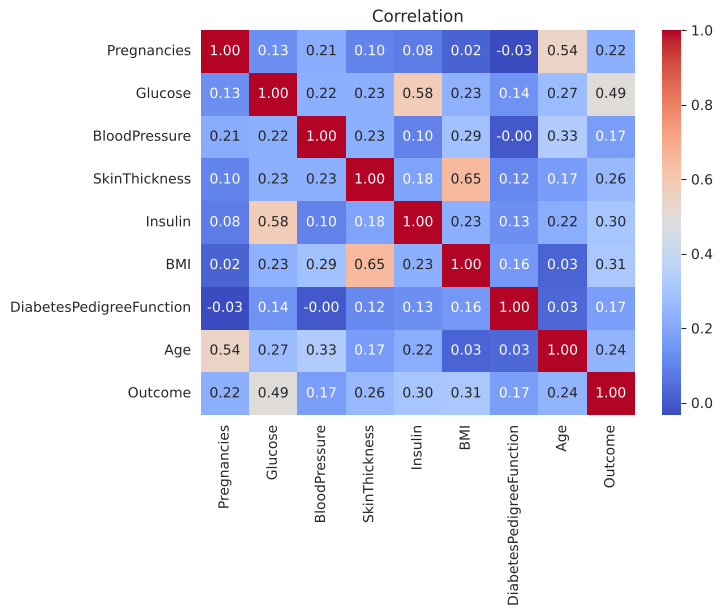

In [4]:
plt.figure(figsize=(7,5)); sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm'); plt.title('Correlation'); plt.show()

In [5]:
X = df.drop('Outcome', axis=1); y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


## Build the models
Each model is a pipeline: median-impute → scale → model (imputing inside the pipeline avoids data leakage).

In [6]:
def pipe(model): return make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), model)
models = {
 'Logistic Regression': pipe(LogisticRegression(max_iter=1000)),
 'Decision Tree':       pipe(DecisionTreeClassifier(random_state=42)),
 'Random Forest':       pipe(RandomForestClassifier(random_state=42)),
 'KNN':                 pipe(KNeighborsClassifier()),
 'SVM':                 pipe(SVC()),
}
rows, cms = [], {}
for name, m in models.items():
    m.fit(X_train, y_train); p = m.predict(X_test)
    rows.append([name, accuracy_score(y_test,p), precision_score(y_test,p), recall_score(y_test,p), f1_score(y_test,p)])
    cms[name] = confusion_matrix(y_test, p)
results = pd.DataFrame(rows, columns=['Model','Accuracy','Precision','Recall','F1']).set_index('Model').round(3)
results.sort_values('F1', ascending=False)

,Accuracy,Precision,Recall,F1
Model,,,,
Random Forest,0.773,0.702,0.611,0.653
KNN,0.753,0.660,0.611,0.635
SVM,0.740,0.652,0.556,0.600
Logistic Regression,0.708,0.600,0.500,0.545
Decision Tree,0.682,0.553,0.481,0.515


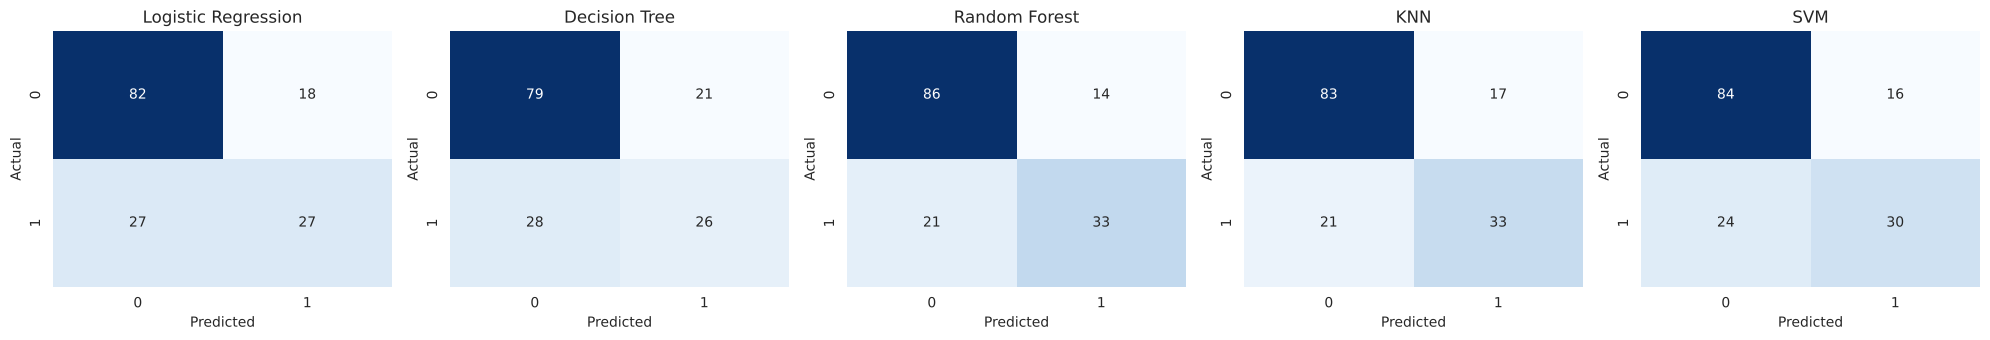

In [7]:
fig, axes = plt.subplots(1,5, figsize=(20,3.5))
for ax,(name,cm) in zip(axes,cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

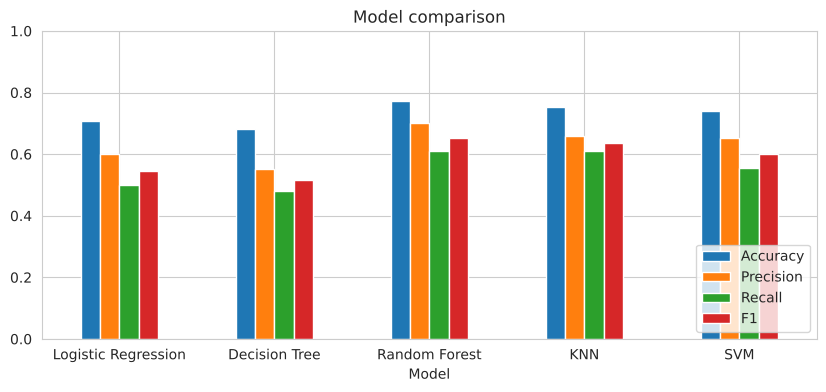

In [8]:
results.plot.bar(figsize=(10,4), ylim=(0,1)); plt.title('Model comparison'); plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.show()

## Summary & recommendation

In [9]:
from IPython.display import Markdown
best = results['F1'].idxmax(); best_acc = results['Accuracy'].idxmax(); best_rec = results['Recall'].idxmax()
Markdown(f'''**Summary table** (test set, 154 patients):

{results.sort_values('F1', ascending=False).to_markdown()}

**Recommendation:** **{best}** is the best overall (highest F1 = {results.loc[best,'F1']:.3f}).
- Highest accuracy: {best_acc} ({results.loc[best_acc,'Accuracy']:.3f}); highest recall: {best_rec} ({results.loc[best_rec,'Recall']:.3f}).
- For a medical problem, **recall** matters a lot — a missed diabetic patient (false negative) is worse than a false alarm. So F1 / recall are better guides than accuracy alone.
- The unpruned Decision Tree overfits (memorises training data), which is why Random Forest (many trees voting), KNN and SVM beat it here.
- Classes are imbalanced (~65% non-diabetic), so accuracy alone can look good even when recall is poor.
- Next week (Week 7): cross-validation + hyperparameter tuning to get a more reliable and better result.''')

**Summary table** (test set, 154 patients):

| Model               |   Accuracy |   Precision |   Recall |    F1 |
|:--------------------|-----------:|------------:|---------:|------:|
| Random Forest       |      0.773 |       0.702 |    0.611 | 0.653 |
| KNN                 |      0.753 |       0.66  |    0.611 | 0.635 |
| SVM                 |      0.74  |       0.652 |    0.556 | 0.6   |
| Logistic Regression |      0.708 |       0.6   |    0.5   | 0.545 |
| Decision Tree       |      0.682 |       0.553 |    0.481 | 0.515 |

**Recommendation:** **Random Forest** is the best overall (highest F1 = 0.653).
- Highest accuracy: Random Forest (0.773); highest recall: Random Forest (0.611).
- For a medical problem, **recall** matters a lot — a missed diabetic patient (false negative) is worse than a false alarm. So F1 / recall are better guides than accuracy alone.
- The unpruned Decision Tree overfits (memorises training data), which is why Random Forest (many trees voting), KNN and SVM beat it here.
- Classes are imbalanced (~65% non-diabetic), so accuracy alone can look good even when recall is poor.
- Next week (Week 7): cross-validation + hyperparameter tuning to get a more reliable and better result.